# EDA Completa do Dataset Titanic

- carregamento e inspeção inicial
- tipagem e dicionário das variáveis
- qualidade dos dados
- tratamento de valores ausentes
- estatística descritiva
- análise univariada
- análise bivariada e multivariada
- detecção de outliers
- engenharia de atributos
- preparação básica para modelagem
- mini modelo de machine learning ao final



## 1. Importação das bibliotecas

In [139]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)


## 2. Carregamento do dataset

Utilizaremos o dataset **Titanic** disponível no `seaborn`.

Esse conjunto de dados é clássico em cursos de EDA e Machine Learning porque contém:

- variáveis numéricas e categóricas
- valores ausentes
- relações históricas intuitivas
- um alvo binário claro: **sobreviveu ou não**


In [140]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 3. Dimensão do dataset

In [141]:
print(f"Linhas: {df.shape[0]}")
print(f"Colunas: {df.shape[1]}")

Linhas: 891
Colunas: 15


## 4. Dicionário resumido das variáveis

In [142]:
data_dict = pd.DataFrame({
    "coluna": df.columns,
    "descricao": [
        "Sobreviveu (0 = não, 1 = sim)",
        "Classe do passageiro (1, 2, 3)",
        "Sexo",
        "Idade",
        "Número de irmãos/cônjuges a bordo",
        "Número de pais/filhos a bordo",
        "Tarifa paga",
        "Porto de embarque (C, Q, S)",
        "Classe da viagem (texto)",
        "Categoria da pessoa (man, woman, child)",
        "É homem adulto? (bool)",
        "Convés/cabine (deck)",
        "Cidade/porto de embarque",
        "Passageiro vivo? (texto)",
        "Viajando sozinho? (bool)"
    ]
})

data_dict

,coluna,descricao
0,survived,"Sobreviveu (0 = não, 1 = sim)"
1,pclass,"Classe do passageiro (1, 2, 3)"
2,sex,Sexo
3,age,Idade
4,sibsp,Número de irmãos/cônjuges a bordo
5,parch,Número de pais/filhos a bordo
6,fare,Tarifa paga
7,embarked,"Porto de embarque (C, Q, S)"
8,class,Classe da viagem (texto)
9,who,"Categoria da pessoa (man, woman, child)"


## 5. Visualização inicial

In [143]:
df.sample(10, random_state=42)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
709,1,3,male,NaN,1,1,15.2458,C,Third,man,True,NaN,Cherbourg,yes,False
439,0,2,male,31.0,0,0,10.5000,S,Second,man,True,NaN,Southampton,no,True
840,0,3,male,20.0,0,0,7.9250,S,Third,man,True,NaN,Southampton,no,True
720,1,2,female,6.0,0,1,33.0000,S,Second,child,False,NaN,Southampton,yes,False
39,1,3,female,14.0,1,0,11.2417,C,Third,child,False,NaN,Cherbourg,yes,False
290,1,1,female,26.0,0,0,78.8500,S,First,woman,False,NaN,Southampton,yes,True
300,1,3,female,NaN,0,0,7.7500,Q,Third,woman,False,NaN,Queenstown,yes,True
333,0,3,male,16.0,2,0,18.0000,S,Third,man,True,NaN,Southampton,no,False
208,1,3,female,16.0,0,0,7.7500,Q,Third,woman,False,NaN,Queenstown,yes,True
136,1,1,female,19.0,0,2,26.2833,S,First,woman,False,D,Southampton,yes,False


## 6. Estrutura e tipos dos dados

In [144]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


## 7. Estatísticas descritivas das variáveis numéricas

In [145]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
sibsp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


## 8. Estatísticas das variáveis categóricas

In [146]:
df.describe(include=["object", "category", "bool"]).T

,count,unique,top,freq
sex,891,2,male,577
embarked,889,3,S,644
class,891,3,Third,491
who,891,3,man,537
adult_male,891,2,True,537
deck,203,7,C,59
embark_town,889,3,Southampton,644
alive,891,2,no,549
alone,891,2,True,537


## 9. Verificação de valores ausentes

Em EDA, uma das primeiras perguntas é:

- **Há dados faltantes?**
- **Em quais colunas?**
- **Qual a proporção desses valores ausentes?**


In [147]:
missing_abs = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)

missing_table = pd.DataFrame({
    "faltantes": missing_abs,
    "percentual_%": missing_pct.round(2)
})

missing_table[missing_table["faltantes"] > 0]

,faltantes,percentual_%
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


### 9.1 Visualização dos faltantes

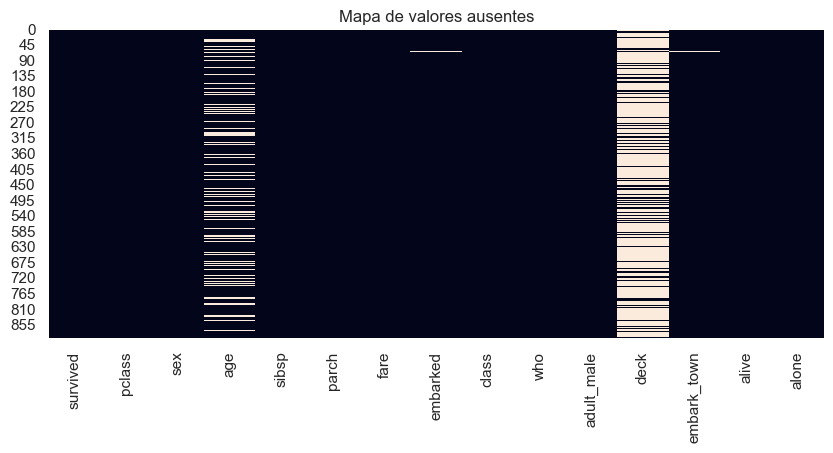

In [148]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isna(), cbar=False)
plt.title("Mapa de valores ausentes")
plt.show()

## 10. Perguntas iniciais de negócio / análise

Antes de sair aplicando funções, uma EDA estruturada deve responder perguntas como:

1. Qual é a taxa geral de sobrevivência?
2. Sexo influenciou a sobrevivência?
3. Classe social influenciou?
4. Idade influenciou?
5. Tarifa paga tem relação com sobrevivência?
6. Pessoas sozinhas sobreviveram menos?
7. O porto de embarque parece ter alguma relação?


## 11. Taxa geral de sobrevivência

In [149]:
survival_rate = df["survived"].mean()
print(f"Taxa geral de sobrevivência: {survival_rate:.2%}")

df["survived"].value_counts().rename(index={0: "Não sobreviveu", 1: "Sobreviveu"})

Taxa geral de sobrevivência: 38.38%


survived
Não sobreviveu    549
Sobreviveu        342
Name: count, dtype: int64

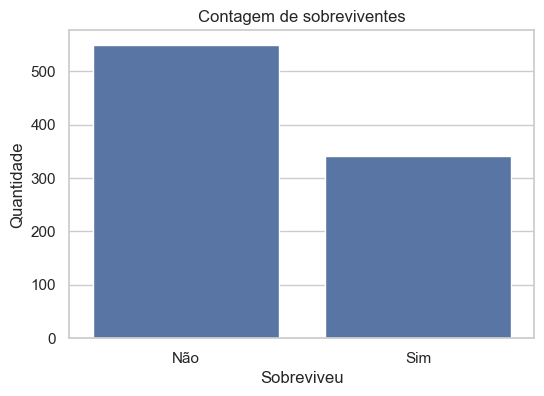

In [150]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="survived")
plt.title("Contagem de sobreviventes")
plt.xticks([0,1], ["Não", "Sim"])
plt.xlabel("Sobreviveu")
plt.ylabel("Quantidade")
plt.show()

## 12. Análise univariada — variáveis numéricas

### 12.1 Idade

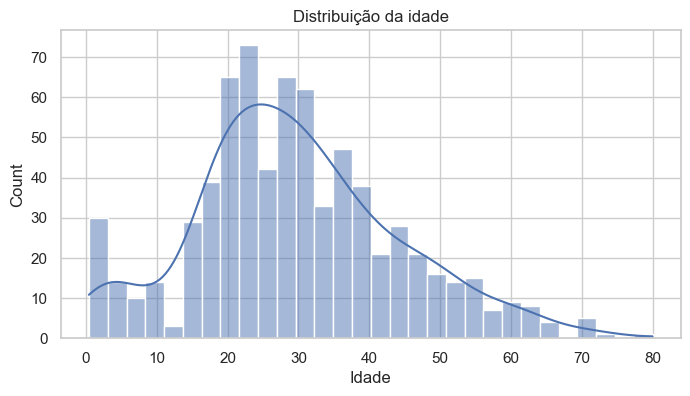

In [151]:
plt.figure(figsize=(8,4))
sns.histplot(df["age"].dropna(), bins=30, kde=True)
plt.title("Distribuição da idade")
plt.xlabel("Idade")
plt.show()

In [152]:
print("Idade média:", round(df["age"].mean(), 2))
print("Idade mediana:", round(df["age"].median(), 2))
print("Idade mínima:", df["age"].min())
print("Idade máxima:", df["age"].max())

Idade média: 29.7
Idade mediana: 28.0
Idade mínima: 0.42
Idade máxima: 80.0


### 12.2 Tarifa

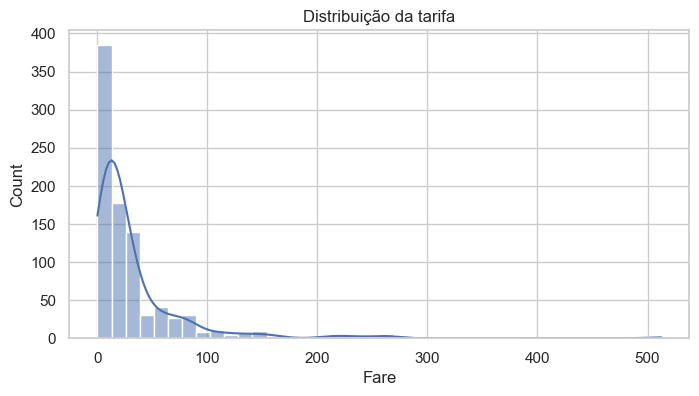

In [153]:
plt.figure(figsize=(8,4))
sns.histplot(df["fare"], bins=40, kde=True)
plt.title("Distribuição da tarifa")
plt.xlabel("Fare")
plt.show()

In [154]:
df["fare"].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: fare, dtype: float64

### 12.3 sibsp e parch

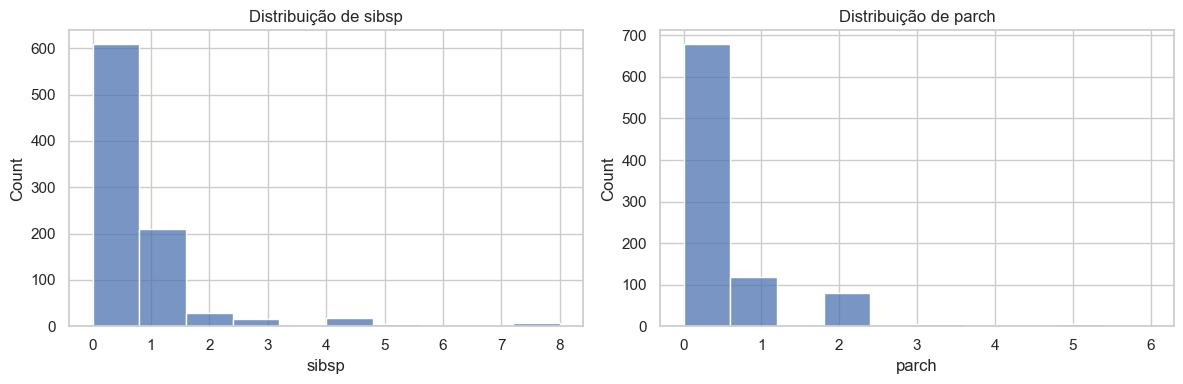

In [155]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.histplot(df["sibsp"], bins=10, ax=axes[0])
axes[0].set_title("Distribuição de sibsp")

sns.histplot(df["parch"], bins=10, ax=axes[1])
axes[1].set_title("Distribuição de parch")

plt.tight_layout()
plt.show()

## 13. Análise univariada — variáveis categóricas

In [156]:
categorical_cols = ["sex", "class", "embark_town", "who", "alone"]
for col in categorical_cols:
    print(f"\n===== {col.upper()} =====")
    display(df[col].value_counts(dropna=False))


===== SEX =====


sex
male      577
female    314
Name: count, dtype: int64


===== CLASS =====


class
Third     491
First     216
Second    184
Name: count, dtype: int64


===== EMBARK_TOWN =====


embark_town
Southampton    644
Cherbourg      168
Queenstown      77
NaN              2
Name: count, dtype: int64


===== WHO =====


who
man      537
woman    271
child     83
Name: count, dtype: int64


===== ALONE =====


alone
True     537
False    354
Name: count, dtype: int64

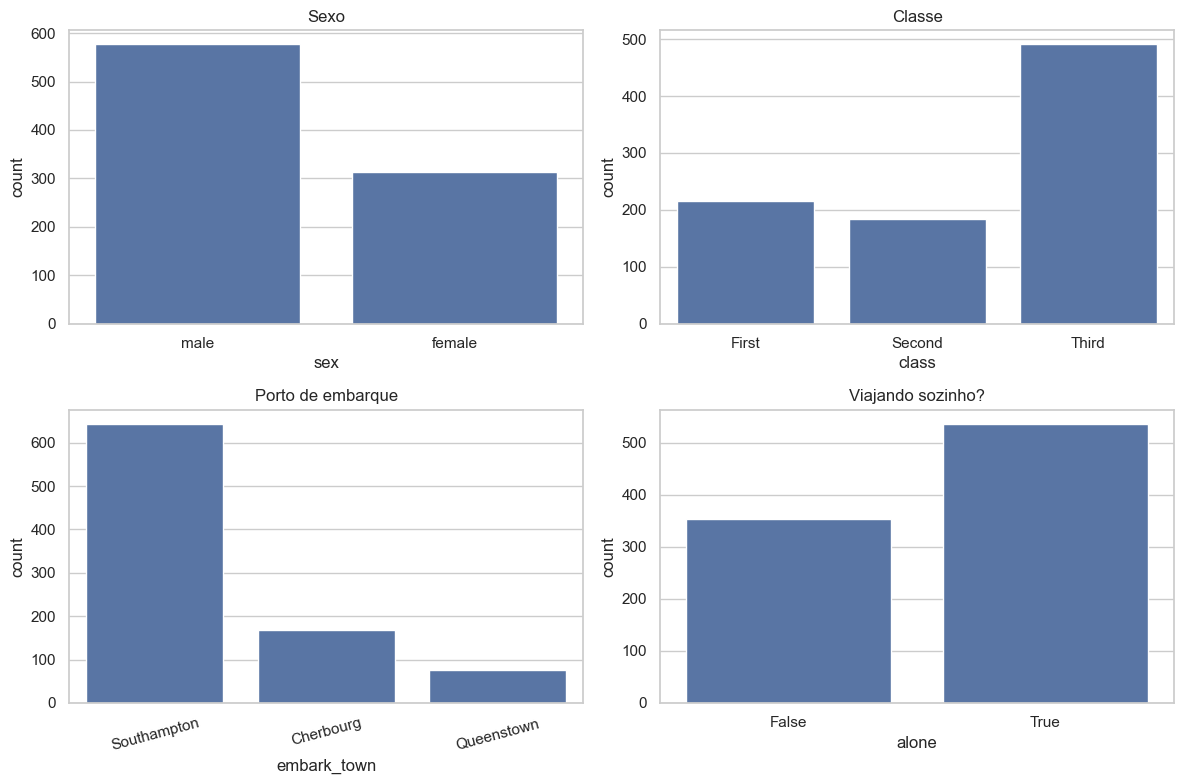

In [157]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))

sns.countplot(data=df, x="sex", ax=axes[0,0])
axes[0,0].set_title("Sexo")

sns.countplot(data=df, x="class", ax=axes[0,1], order=["First", "Second", "Third"])
axes[0,1].set_title("Classe")

sns.countplot(data=df, x="embark_town", ax=axes[1,0])
axes[1,0].set_title("Porto de embarque")
axes[1,0].tick_params(axis="x", rotation=15)

sns.countplot(data=df, x="alone", ax=axes[1,1])
axes[1,1].set_title("Viajando sozinho?")

plt.tight_layout()
plt.show()

## 14. Análise bivariada — sobrevivência por categorias

### 14.1 Sobrevivência por sexo

In [158]:
survival_by_sex = df.groupby("sex")["survived"].mean().sort_values(ascending=False)
survival_by_sex

sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

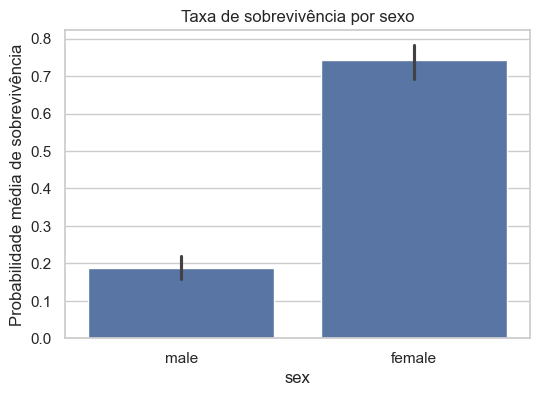

In [159]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x="sex", y="survived", estimator=np.mean)
plt.title("Taxa de sobrevivência por sexo")
plt.ylabel("Probabilidade média de sobrevivência")
plt.show()

### 14.2 Sobrevivência por classe

In [160]:
survival_by_class = df.groupby("class")["survived"].mean().reindex(["First", "Second", "Third"])
survival_by_class

class
First     0.629630
Second    0.472826
Third     0.242363
Name: survived, dtype: float64

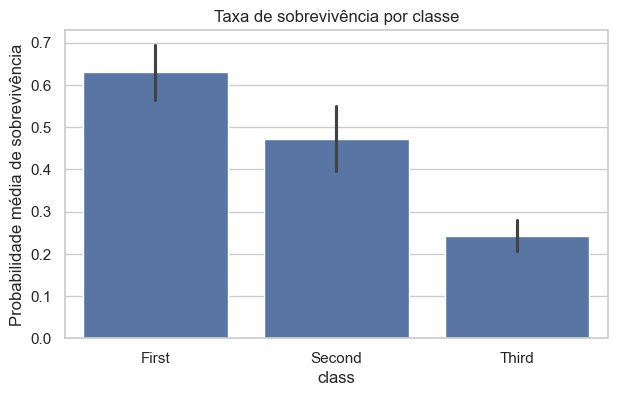

In [161]:
plt.figure(figsize=(7,4))
sns.barplot(data=df, x="class", y="survived", order=["First", "Second", "Third"])
plt.title("Taxa de sobrevivência por classe")
plt.ylabel("Probabilidade média de sobrevivência")
plt.show()

### 14.3 Sobrevivência por porto de embarque

In [162]:
df.groupby("embark_town")["survived"].mean().sort_values(ascending=False)

embark_town
Cherbourg      0.553571
Queenstown     0.389610
Southampton    0.336957
Name: survived, dtype: float64

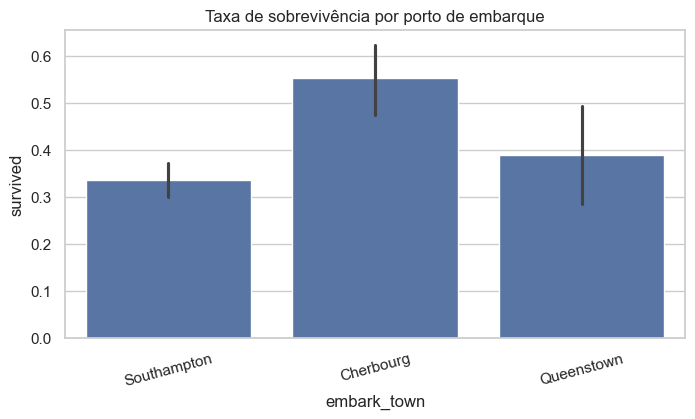

In [163]:
plt.figure(figsize=(8,4))
sns.barplot(data=df, x="embark_town", y="survived")
plt.title("Taxa de sobrevivência por porto de embarque")
plt.xticks(rotation=15)
plt.show()

### 14.4 Sobrevivência por condição de viajar sozinho

In [164]:
df.groupby("alone")["survived"].mean()

alone
False    0.505650
True     0.303538
Name: survived, dtype: float64

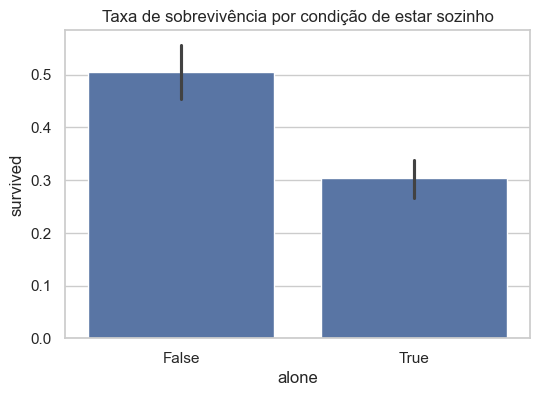

In [165]:
plt.figure(figsize=(6,4))
sns.barplot(data=df, x="alone", y="survived")
plt.title("Taxa de sobrevivência por condição de estar sozinho")
plt.show()

## 15. Análise bivariada — idade e sobrevivência

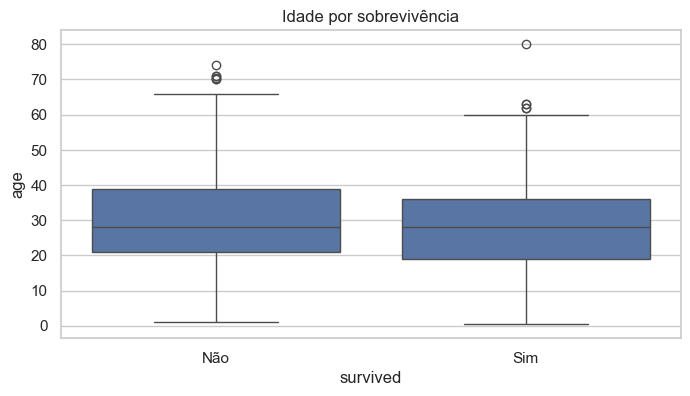

In [166]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="survived", y="age")
plt.title("Idade por sobrevivência")
plt.xticks([0,1], ["Não", "Sim"])
plt.show()

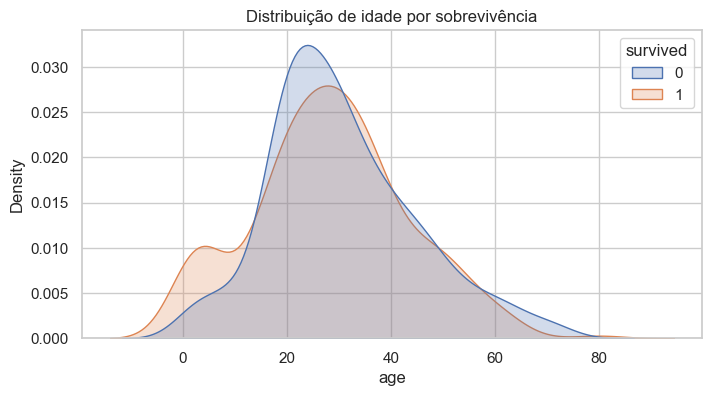

In [167]:
plt.figure(figsize=(8,4))
sns.kdeplot(data=df, x="age", hue="survived", common_norm=False, fill=True)
plt.title("Distribuição de idade por sobrevivência")
plt.show()

## 16. Análise bivariada — tarifa e sobrevivência

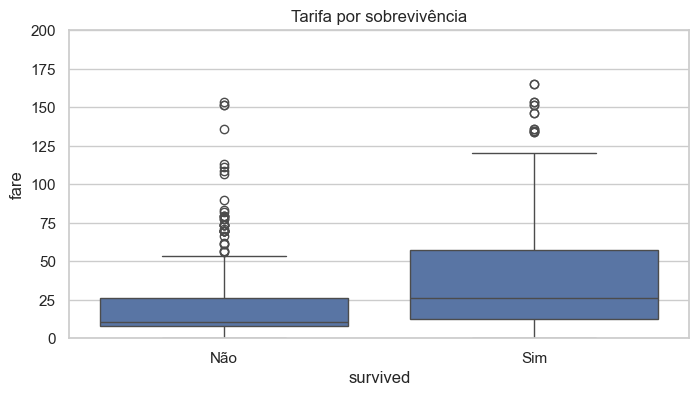

In [168]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="survived", y="fare")
plt.title("Tarifa por sobrevivência")
plt.xticks([0,1], ["Não", "Sim"])
plt.ylim(0, 200)
plt.show()

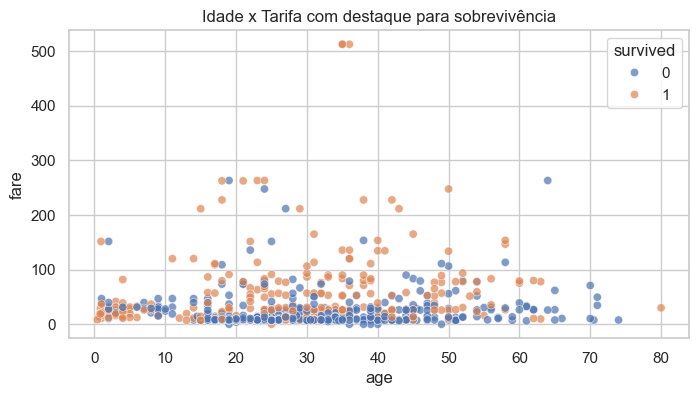

In [169]:
plt.figure(figsize=(8,4))
sns.scatterplot(data=df, x="age", y="fare", hue="survived", alpha=0.7)
plt.title("Idade x Tarifa com destaque para sobrevivência")
plt.show()

## 17. Análise multivariada

### 17.1 Sobrevivência por sexo e classe

In [170]:
survival_sex_class = pd.pivot_table(
    df,
    values="survived",
    index="sex",
    columns="class",
    aggfunc="mean"
)
survival_sex_class

class,First,Second,Third
sex,,,
female,0.968085,0.921053,0.500000
male,0.368852,0.157407,0.135447


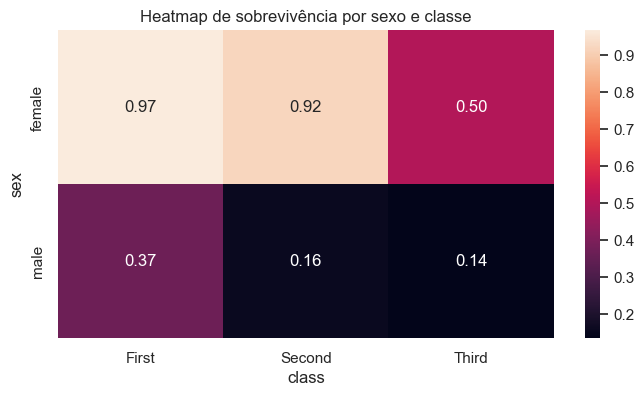

In [171]:
plt.figure(figsize=(8,4))
sns.heatmap(survival_sex_class, annot=True, fmt=".2f")
plt.title("Heatmap de sobrevivência por sexo e classe")
plt.show()

### 17.2 Sobrevivência por sexo e faixa etária categórica (who)

In [172]:
pd.crosstab(df["who"], df["survived"], normalize="index")

survived,0,1
who,,
child,0.409639,0.590361
man,0.836127,0.163873
woman,0.243542,0.756458


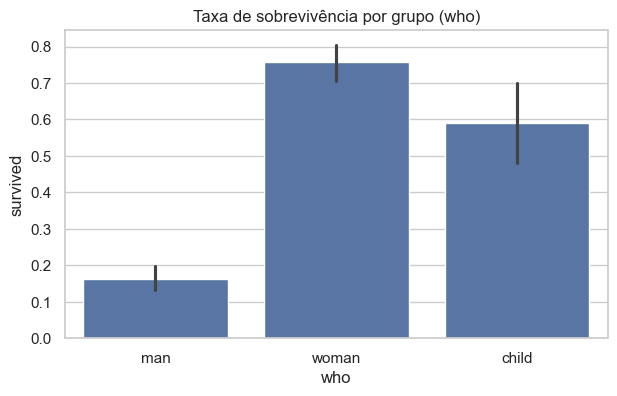

In [173]:
plt.figure(figsize=(7,4))
sns.barplot(data=df, x="who", y="survived", estimator=np.mean)
plt.title("Taxa de sobrevivência por grupo (who)")
plt.show()

## 18. Correlação entre variáveis numéricas

In [174]:
numeric_df = df.select_dtypes(include=np.number)
numeric_df.corr()

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.338481,-0.077221,-0.035322,0.081629,0.257307
pclass,-0.338481,1.000000,-0.369226,0.083081,0.018443,-0.549500
age,-0.077221,-0.369226,1.000000,-0.308247,-0.189119,0.096067
sibsp,-0.035322,0.083081,-0.308247,1.000000,0.414838,0.159651
parch,0.081629,0.018443,-0.189119,0.414838,1.000000,0.216225
fare,0.257307,-0.549500,0.096067,0.159651,0.216225,1.000000


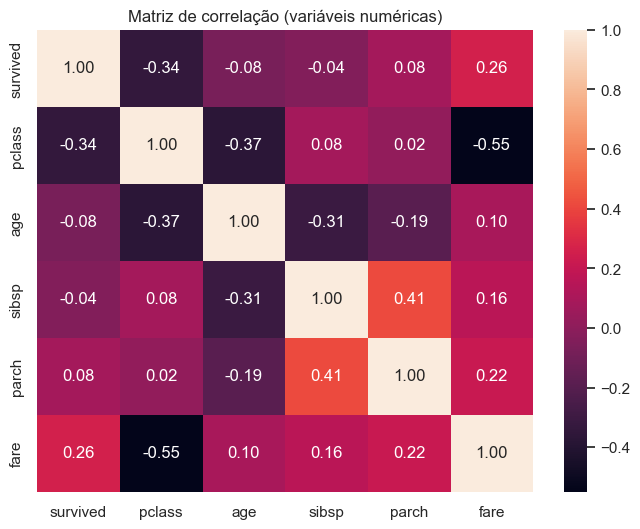

In [175]:
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f")
plt.title("Matriz de correlação (variáveis numéricas)")
plt.show()

### Comentário didático

A correlação mede **associação linear** entre variáveis numéricas.

Interpretação geral:

- **+1**: correlação positiva forte
- **0**: pouca ou nenhuma correlação linear
- **-1**: correlação negativa forte

Em datasets reais, correlação não implica causalidade.


## 19. Detecção de outliers

### 19.1 Boxplots

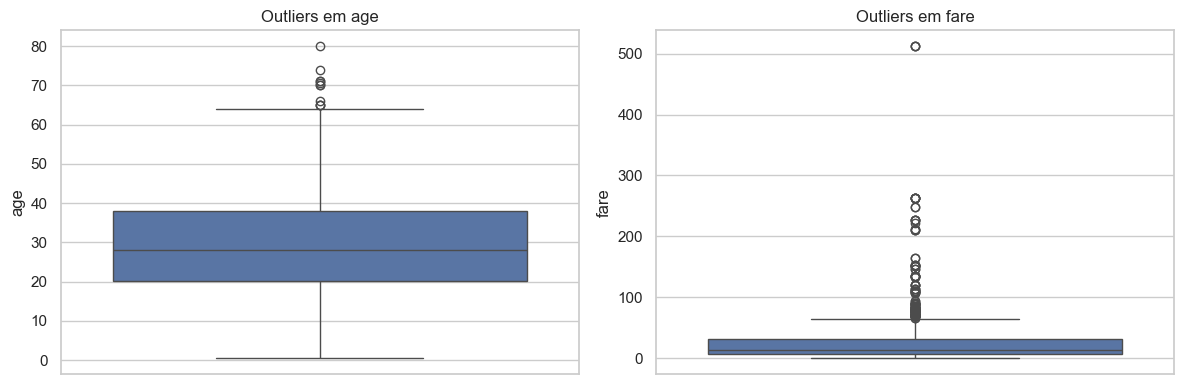

In [176]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.boxplot(y=df["age"], ax=axes[0])
axes[0].set_title("Outliers em age")

sns.boxplot(y=df["fare"], ax=axes[1])
axes[1].set_title("Outliers em fare")

plt.tight_layout()
plt.show()

### 19.2 Método do IQR para `fare`

In [177]:
Q1 = df["fare"].quantile(0.25)
Q3 = df["fare"].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers_fare = df[(df["fare"] < lower) | (df["fare"] > upper)]

print(f"Q1 = {Q1:.2f}")
print(f"Q3 = {Q3:.2f}")
print(f"IQR = {IQR:.2f}")
print(f"Limite inferior = {lower:.2f}")
print(f"Limite superior = {upper:.2f}")
print(f"Quantidade de outliers em fare = {len(outliers_fare)}")

Q1 = 7.91
Q3 = 31.00
IQR = 23.09
Limite inferior = -26.72
Limite superior = 65.63
Quantidade de outliers em fare = 116


In [178]:
outliers_fare[["fare", "class", "sex", "survived"]].sort_values("fare", ascending=False).head(10)

,fare,class,sex,survived
258,512.3292,First,female,1
737,512.3292,First,male,1
679,512.3292,First,male,1
27,263.0000,First,male,0
341,263.0000,First,female,1
438,263.0000,First,male,0
88,263.0000,First,female,1
311,262.3750,First,female,1
742,262.3750,First,female,1
299,247.5208,First,female,1


## 20. Engenharia de atributos

Em EDA aplicada, criar novas variáveis costuma ajudar bastante na interpretação e depois na modelagem.

Vamos criar:
- `family_size` = sibsp + parch + 1
- `is_child` = idade < 12
- `fare_per_person` = tarifa por pessoa do grupo
- `age_group` = faixas de idade


In [179]:
df_eda = df.copy()

df_eda["family_size"] = df_eda["sibsp"] + df_eda["parch"] + 1
df_eda["is_child"] = df_eda["age"] < 12
df_eda["fare_per_person"] = df_eda["fare"] / df_eda["family_size"]

df_eda["age_group"] = pd.cut(
    df_eda["age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Criança", "Adolescente", "Jovem adulto", "Adulto", "Idoso"]
)

df_eda.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,family_size,is_child,fare_per_person,age_group
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False,2,False,3.62500,Jovem adulto
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,2,False,35.64165,Adulto
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True,1,False,7.92500,Jovem adulto
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,2,False,26.55000,Jovem adulto
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True,1,False,8.05000,Jovem adulto


### 20.1 Sobrevivência por tamanho da família

In [180]:
df_eda.groupby("family_size")["survived"].mean()

family_size
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: survived, dtype: float64

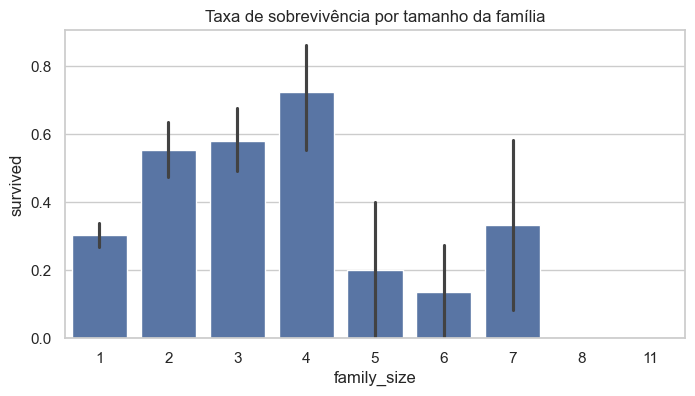

In [181]:
plt.figure(figsize=(8,4))
sns.barplot(data=df_eda, x="family_size", y="survived", estimator=np.mean)
plt.title("Taxa de sobrevivência por tamanho da família")
plt.show()

### 20.2 Sobrevivência por faixa etária

In [182]:
df_eda.groupby("age_group", observed=False)["survived"].mean()

age_group
Criança         0.579710
Adolescente     0.428571
Jovem adulto    0.382682
Adulto          0.400000
Idoso           0.227273
Name: survived, dtype: float64

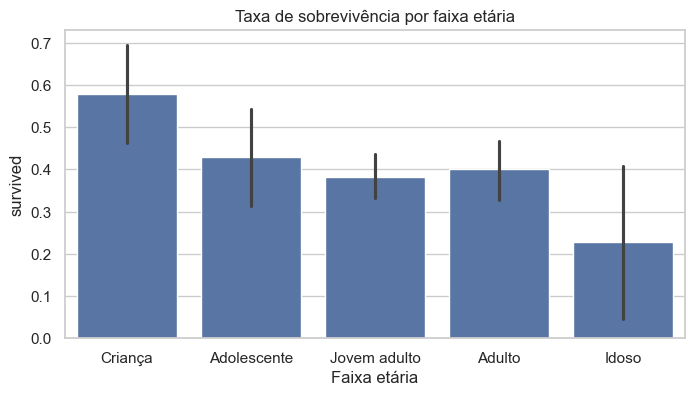

In [183]:
plt.figure(figsize=(8,4))
sns.barplot(data=df_eda, x="age_group", y="survived", estimator=np.mean)
plt.title("Taxa de sobrevivência por faixa etária")
plt.xlabel("Faixa etária")
plt.show()

### 20.3 Tarifa por pessoa e sobrevivência

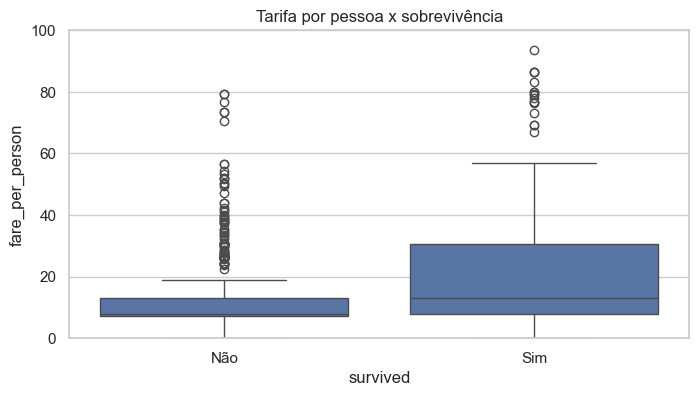

In [184]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df_eda, x="survived", y="fare_per_person")
plt.title("Tarifa por pessoa x sobrevivência")
plt.xticks([0,1], ["Não", "Sim"])
plt.ylim(0, 100)
plt.show()

## 21. Tratamento didático de valores ausentes

Não existe um único tratamento universal para faltantes.

Para fins didáticos, vamos mostrar algumas estratégias:

- numéricos: preencher com mediana
- categóricos: preencher com moda
- às vezes remover colunas com excesso de faltantes


In [185]:
df_eda.isna().sum().sort_values(ascending=False)

deck               688
age                177
age_group          177
embark_town          2
embarked             2
survived             0
pclass               0
sex                  0
fare                 0
parch                0
sibsp                0
adult_male           0
who                  0
class                0
alive                0
alone                0
family_size          0
is_child             0
fare_per_person      0
dtype: int64

In [186]:
df_clean = df_eda.copy()

# Exemplo didático: remover coluna com muitos faltantes
df_clean = df_clean.drop(columns=["deck"])

# Preenchimento simples
df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median())
df_clean["embarked"] = df_clean["embarked"].fillna(df_clean["embarked"].mode()[0])
df_clean["embark_town"] = df_clean["embark_town"].fillna(df_clean["embark_town"].mode()[0])

df_clean.isna().sum().sort_values(ascending=False).head(10)

age_group    177
survived       0
pclass         0
sex            0
sibsp          0
age            0
fare           0
embarked       0
class          0
parch          0
dtype: int64

## 22. Tabelas-resumo úteis em EDA

In [187]:
summary_table = df_clean.groupby(["sex", "class"]).agg(
    passageiros=("survived", "count"),
    taxa_sobrevivencia=("survived", "mean"),
    idade_media=("age", "mean"),
    tarifa_media=("fare", "mean")
).round(2)

summary_table

passageiros  taxa_sobrevivencia  idade_media  tarifa_media
sex    class                                                             
female First            94                0.97        33.98        106.13
       Second           76                0.92        28.70         21.97
       Third           144                0.50        23.57         16.12
male   First           122                0.37        39.00         67.23
       Second          108                0.16        30.51         19.74
       Third           347                0.14        26.91         12.66

## 23. Perguntas analíticas respondidas

Com base nas análises acima, procure responder:

1. Mulheres sobreviveram mais do que homens?
2. Passageiros de primeira classe sobreviveram mais?
3. Crianças tiveram maior chance de sobrevivência?
4. A tarifa parece capturar uma dimensão socioeconômica?
5. Viajar sozinho parece reduzir a chance de sobreviver?
6. O tamanho da família ajuda ou atrapalha?


## 24. Visualizações finais para relatório

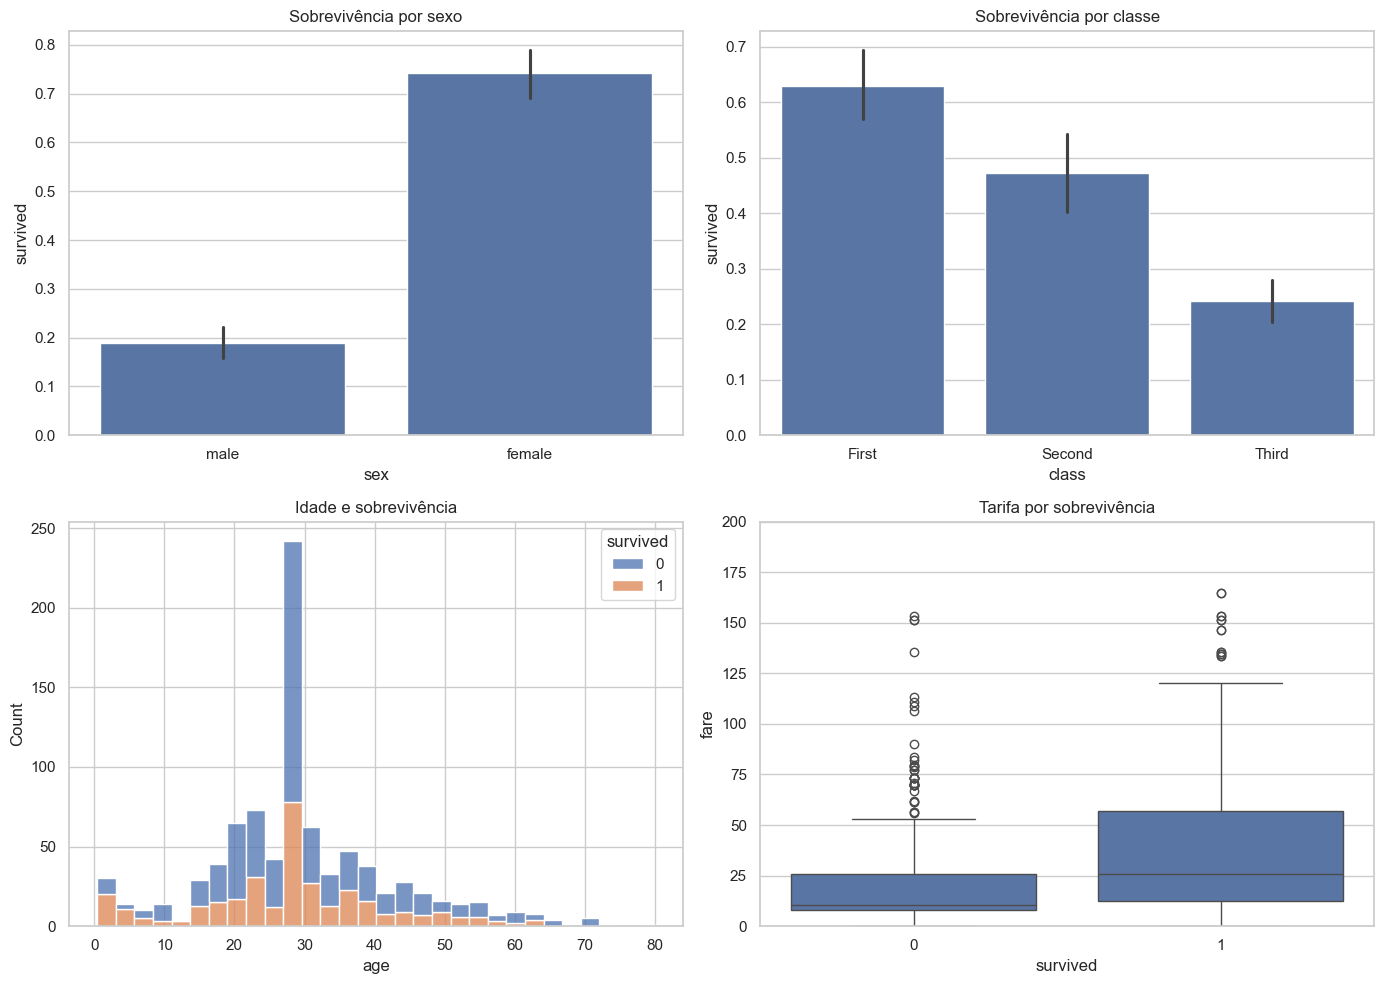

In [188]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))

sns.barplot(data=df_clean, x="sex", y="survived", estimator=np.mean, ax=axes[0,0])
axes[0,0].set_title("Sobrevivência por sexo")

sns.barplot(data=df_clean, x="class", y="survived", order=["First", "Second", "Third"], ax=axes[0,1])
axes[0,1].set_title("Sobrevivência por classe")

sns.histplot(data=df_clean, x="age", hue="survived", bins=30, multiple="stack", ax=axes[1,0])
axes[1,0].set_title("Idade e sobrevivência")

sns.boxplot(data=df_clean, x="survived", y="fare", ax=axes[1,1])
axes[1,1].set_title("Tarifa por sobrevivência")
axes[1,1].set_ylim(0, 200)

plt.tight_layout()
plt.show()

## 25. Preparação para Machine Learning

Agora vamos montar uma preparação **mínima e didática** para modelagem.

Observação importante:
- aqui o objetivo **não é otimizar o melhor modelo**
- o objetivo é mostrar como a EDA prepara o caminho para ML


In [189]:
target = "survived"

features = [
    "pclass", "sex", "age", "sibsp", "parch", "fare",
    "embarked", "alone", "family_size", "is_child"
]

X = df_clean[features]
y = df_clean[target]

X.head()

,pclass,sex,age,sibsp,parch,fare,embarked,alone,family_size,is_child
0,3,male,22.0,1,0,7.2500,S,False,2,False
1,1,female,38.0,1,0,71.2833,C,False,2,False
2,3,female,26.0,0,0,7.9250,S,True,1,False
3,1,female,35.0,1,0,53.1000,S,False,2,False
4,3,male,35.0,0,0,8.0500,S,True,1,False


### 25.1 Separação treino/teste

In [190]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (712, 10)
Teste: (179, 10)


### 25.2 Pipeline de pré-processamento

In [191]:
X_train = X_train.copy()
X_test = X_test.copy()

X_train["alone"] = X_train["alone"].astype(int)
X_test["alone"] = X_test["alone"].astype(int)

X_train["is_child"] = X_train["is_child"].astype(int)
X_test["is_child"] = X_test["is_child"].astype(int)

numeric_features = ["pclass", "age", "sibsp", "parch", "fare", "family_size", "alone", "is_child"]
categorical_features = ["sex", "embarked"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="constant", fill_value="missing")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])




## 26. Mini modelo 1 — Regressão Logística

In [192]:
logreg_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

logreg_model.fit(X_train, y_train)
y_pred_log = logreg_model.predict(X_test)

print("Acurácia:", round(accuracy_score(y_test, y_pred_log), 4))
print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred_log))

Acurácia: 0.8212

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86       110
           1       0.81      0.70      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



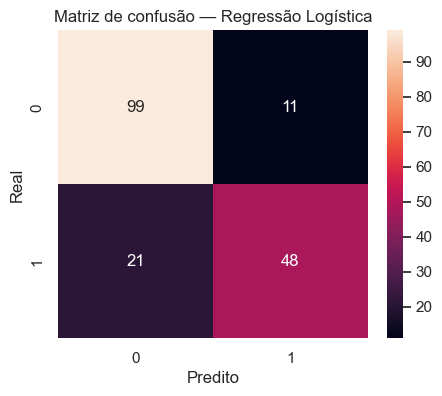

In [193]:
cm_log = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(5,4))
sns.heatmap(cm_log, annot=True, fmt="d")
plt.title("Matriz de confusão — Regressão Logística")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

## 27. Mini modelo 2 — Árvore de Decisão

In [194]:
tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(max_depth=4, random_state=42))
])

tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

print("Acurácia:", round(accuracy_score(y_test, y_pred_tree), 4))
print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred_tree))

Acurácia: 0.7821

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.76      0.94      0.84       110
           1       0.84      0.54      0.65        69

    accuracy                           0.78       179
   macro avg       0.80      0.74      0.75       179
weighted avg       0.79      0.78      0.77       179



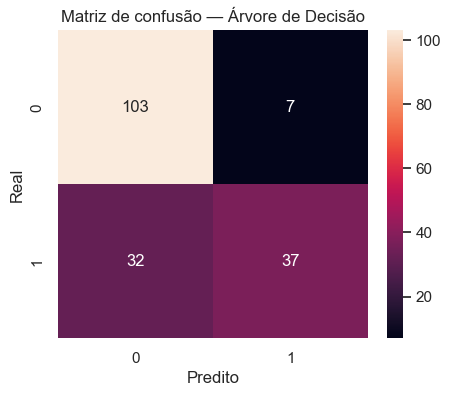

In [195]:
cm_tree = confusion_matrix(y_test, y_pred_tree)

plt.figure(figsize=(5,4))
sns.heatmap(cm_tree, annot=True, fmt="d")
plt.title("Matriz de confusão — Árvore de Decisão")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

## 28. EDA antes da modelagem


- variáveis com forte associação com o alvo
- presença de dados faltantes
- variáveis derivadas úteis (`family_size`, `is_child`)
- relações entre classe social, tarifa e sobrevivência

 Resultado mais interpretável e menos propenso a erros.


## 29. Conclusões principais do dataset Titanic

Principais insights que costumam aparecer nesta análise:

1. **Mulheres sobreviveram muito mais do que homens.**
2. **Passageiros da primeira classe tiveram vantagem significativa.**
3. **A tarifa paga está associada a maior chance de sobrevivência.**
4. **Crianças parecem ter tido maior proteção relativa.**
5. **Viajar sozinho tende a estar associado a menor sobrevivência, embora isso dependa de outras variáveis.**
6. **Classe, sexo e tarifa são variáveis especialmente informativas.**


## 30. Exercícios propostos

### Exercício 1
Calcule a taxa de sobrevivência por `embarked`.

### Exercício 2
Compare a idade média de sobreviventes e não sobreviventes.

### Exercício 3
Crie uma nova variável indicando se o passageiro tinha família grande (`family_size >= 4`) e analise a sobrevivência.

### Exercício 4
Monte um gráfico comparando `fare` por `class`.

### Exercício 5
Treine outro modelo usando apenas as variáveis:
- `sex`
- `class`
- `age`
- `fare`

e compare com os resultados acima.


## 31. Desafio final

Produza um mini relatório respondendo:

- Quais três variáveis parecem mais importantes para prever sobrevivência?
- Quais limitações esse dataset possui?
- Quais cuidados você tomaria antes de colocar um modelo em produção?
